# Predict Customer Churn #
This is my first Kaggle competition entry, working on on season 6 episode 3 of the playground predictions series - Predict Customer Churn

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

Let's import our data as pandas dataframes for easy manipulation.

In [2]:
train_df = pd.read_csv("data/train.csv")

N_tr = len(train_df)

print(f"Training Data Length: {N_tr}")

Training Data Length: 594194


Now let's see what proportion of our customers have a 'Churn' value of yes, which can help us decide whether the results we find later are appropriate.

In [3]:
def p_churn(df):
    n = len(df)
    churn = df["Churn"].map({"Yes": 1, "No": 0})
    churn_total = sum(churn)
    return churn_total / n

In [44]:
def plot_churn_distribution(n, p):
    mean = n*p
    var = mean * (1-p)
    sd = np.sqrt(var)
    x = np.linspace(mean - 3*sd, mean + 3*sd, 100)
    y = np.exp(-(x - mean)**2 / (2 * var)) / np.sqrt(2 * np.pi * var)

    plt.plot(x / n, y)
    plt.title("Distribution of Churn Probability")
    plt.show()



In [45]:
p = p_churn(train_df)

No problems, a miracle! Now we need to clean the data up, categorical data is no good to our model, so we'll use a label encoder to convert our categorical data to data we can use in our model. We use the pd.get_dummies method for this, which converts a categorical data column into several boolean data columns, with the downside that this makes the data significantly harder to read. We should also normalise our data to prevent larger raw values from having a disproportionate impact on our output.

In [46]:
def normalise(df: pd.DataFrame) -> pd.DataFrame:
    types = df.dtypes
    cols =[col for col in df.columns if types[col] != "str" and col != "id"]
    for col in cols:
        df_col = df[col]
        df[col] = (df_col-df_col.mean())/df_col.std()
    return df

In [7]:
def encode_labels(df: pd.DataFrame) -> pd.DataFrame:
    le = LabelEncoder()
    cols = [col for col in df.columns if df.dtypes[col] == "str"]
    for col in cols:
        df[col] = pd.factorize(df[col])[0]
    return df

In [8]:
def encode_one_hot(df: pd.DataFrame) -> pd.DataFrame:
    types = df.dtypes
    df = pd.get_dummies(df, columns=[col for col in df.columns if types[col] == "str"])
    return df

In [9]:
def prepare_data(df):
    d = {"Yes": True, "No": False}
    try:
        y = df["Churn"].map(d)
        x = df.iloc[:, 1:-1]
        x = encode_labels(normalise(x))
        data = pd.concat([x, y], axis=1)
    except KeyError:
        data = encode_labels(normalise(df.iloc[:, 1:]))

    return data

In [10]:
train_df_prepared = prepare_data(train_df)

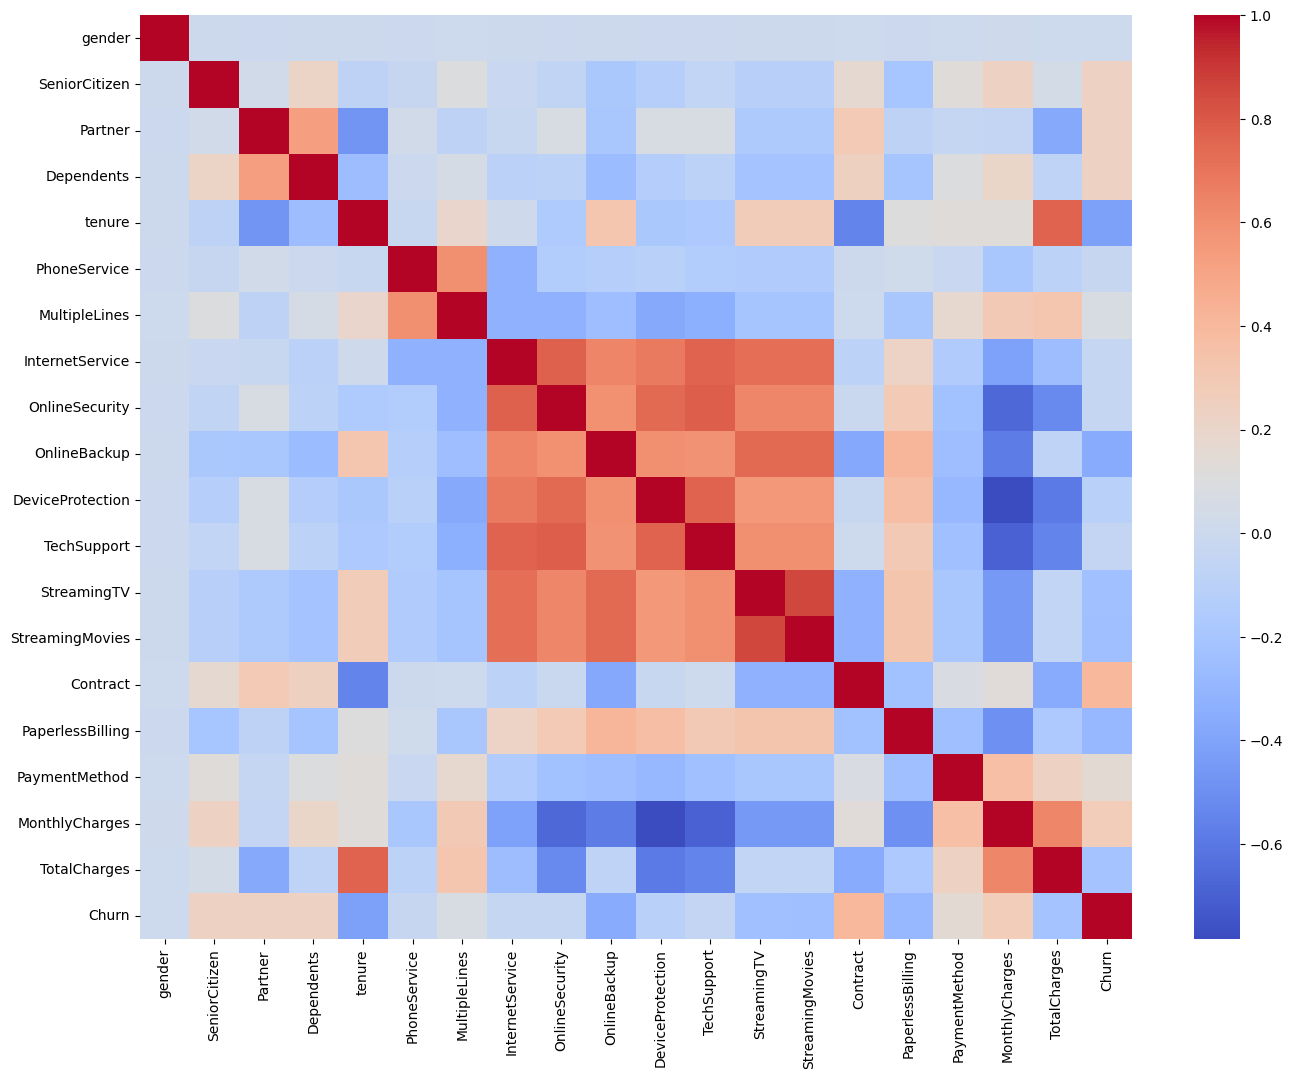

In [11]:
corr_matrix = train_df_prepared.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

The most important row to consider here is of course 'Churn', and we can see fair correlation with contract type and, along with some other properties

We don't have access to the "Churn" variable for the data in test.csv, so we will use a subset of our training database as our test data during the training of the model. This is important to avoid overfitting and ensure appropriate progress of the model, and will help to diagnose problems in the future.

In [12]:
def train_test_split(df, frac = 0.2):
    test = df.sample(frac = frac, axis = 0)
    train = df.drop(index=test.index)
    x_train = torch.tensor(train.iloc[:,:-1].values).to(torch.float32)
    y_train = torch.tensor(train.iloc[:,-1].values).to(torch.float32)
    y_train = torch.tensor(train.iloc[:,-1].values).to(torch.float32).requires_grad_(True)
    x_test = torch.tensor(test.iloc[:,:-1].values, requires_grad=True).to(torch.float32)
    y_test = torch.tensor(test.iloc[:,-1].values).to(torch.float32).requires_grad_(True)
    return x_train, y_train, x_test, y_test

In [13]:
x_train, y_train, x_test, y_test = train_test_split(train_df_prepared)

Now let's define a neural network using pytorch, with an MLP structure due to our data being tabulated. Our input size is 19, 1 for each column in our dataframe, except 'id' and 'Churn', then we have a hidden layer with 38 nodes, and finally an output layer with a single output, this is our probability of churn for our input.

In [39]:
class mlp_V1(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(19, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fcout = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = F.sigmoid(self.fcout(x))
        return x

In [40]:
def mae_loss(predictions, y):
    predictions = predictions.squeeze()
    e = torch.abs(torch.sub(predictions, y))
    return torch.mean(e)

def mse_loss(predictions, y):
    predictions = predictions.squeeze()
    e2 = torch.pow(torch.sub(predictions, y), 2)
    return torch.mean(e2)

In [41]:
def train_model(model: mlp_V1, loss, x_train, y_train, x_test, y_test, lr, steps):
    optimiser = optim.SGD(params=model.parameters(), lr = lr)
    train_loss = np.zeros(steps)
    test_loss = np.zeros(steps)
    for i in range(steps):
        optimiser.zero_grad()

        predictions = model(x_train).requires_grad_(True)
        train_losses = loss(predictions, y_train)
        train_loss[i] = train_losses

        train_losses.backward()
        optimiser.step()

        model.eval()
        test_predictions = model(x_test)
        with torch.no_grad():
            test_loss[i] = loss(test_predictions, y_test)
        model.train()
        if i % int(steps / 10) == 0:
            print(i / int(steps / 10), train_loss[i], test_loss[i])
    print("Final Losses:\n    Training: {:0.5f}\n    Test: {:0.5f}".format(train_loss[-1], test_loss[-1]))
    return model, train_loss, test_loss


In [42]:
def plot_loss(train_loss, test_loss, title):
    plt.plot(train_loss)
    plt.plot(test_loss)
    plt.title(title)
    plt.show()

In [43]:
mse_model = mlp_V1()
mae_model = mlp_V1()
mse_model, mse_trl, mse_tel = train_model(mse_model, mse_loss, x_train, y_train, x_test, y_test, 0.08, 2000)
mae_model, mae_trl, mae_tel = train_model(mae_model, mae_loss, x_train, y_train, x_test, y_test, 0.08, 2000)


0.0 0.24937568604946136 0.23814991116523743
1.0 0.11824777722358704 0.11796078085899353
2.0 0.11003030091524124 0.1097339391708374
3.0 0.10785754024982452 0.10758581012487411
4.0 0.10668356716632843 0.10644299536943436
5.0 0.10585617274045944 0.10564127564430237
6.0 0.10521777719259262 0.10502206534147263
7.0 0.10470376163721085 0.10452194511890411
8.0 0.10427993535995483 0.10410790890455246
9.0 0.10392541438341141 0.10376010090112686
Final Losses:
    Training: 0.10363
    Test: 0.10347
0.0 0.4842481315135956 0.4739890992641449
1.0 0.2283504605293274 0.228314608335495
2.0 0.2264835685491562 0.22648181021213531
3.0 0.2259816825389862 0.22598910331726074
4.0 0.22575512528419495 0.22576695680618286
5.0 0.22562769055366516 0.225642129778862
6.0 0.2255464792251587 0.22556272149085999
7.0 0.22549046576023102 0.22550800442695618
8.0 0.2254495769739151 0.22546815872192383
9.0 0.2254185527563095 0.22543784976005554
Final Losses:
    Training: 0.22539
    Test: 0.22541


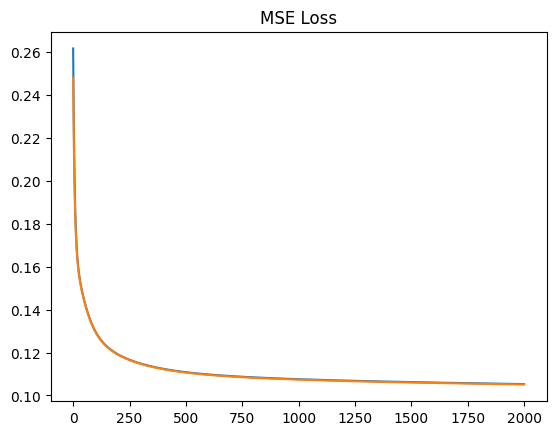

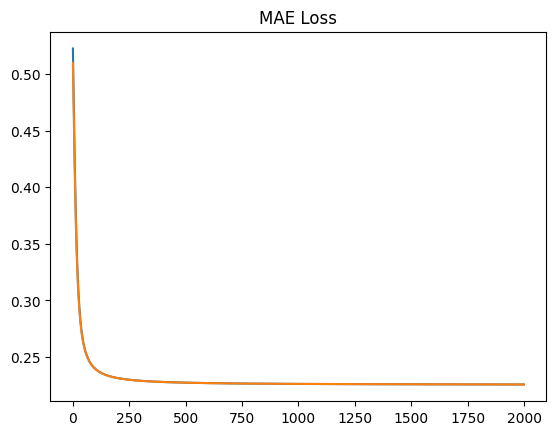

In [25]:
plot_loss(mse_trl, mse_tel, "MSE Loss")
plot_loss(mae_trl, mae_tel, "MAE Loss")

In [58]:
def test_model(model, x, y = None, threshold = 0.5):
    model.eval()
    confusion_matrix = {0: [0, 0], 1: [0, 0]}
    with torch.no_grad():
        predictions = np.array(model(x), dtype=np.float64)
        predicted_churn = np.array([pred > threshold for pred in predictions])
    if y is not None:
        for i in range(len(predicted_churn)):
            actual = y[i].item()
            pred = predicted_churn[i].item()
            confusion_matrix[actual][pred] += 1

    confusion_matrix = pd.DataFrame(data=confusion_matrix)
    return np.concat([predictions, predicted_churn], axis=1), confusion_matrix

In [ ]:
mse_test_result, mse_confusion_matrix = test_model(mse_model, x_test, y_test)
print(mse_confusion_matrix)
mae_test_result, mae_confusion_matrix = test_model(mae_model, x_test, y_test)
print(mae_confusion_matrix)

C:\Users\tenny\AppData\Local\Temp\ipykernel_36736\2944636958.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  predictions = np.array(model(x), dtype=np.float64)


       0      1
0  90125  18544
1   1948   8222


C:\Users\tenny\AppData\Local\Temp\ipykernel_36736\2944636958.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  predictions = np.array(model(x), dtype=np.float64)


       0      1
0  84329  10133
1   7744  16633


C:\Users\tenny\AppData\Local\Temp\ipykernel_36736\2944636958.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  predictions = np.array(model(x), dtype=np.float64)


       0      1
0  92073  26766
1      0      0


Let's try our MSE based model on a subset of the validation data to see what we predict.

In [37]:
valid_df = pd.read_csv("data/test.csv")
x_valid = torch.tensor(prepare_data(valid_df).values).to(torch.float32).requires_grad_(True)

C:\Users\tenny\AppData\Local\Temp\ipykernel_36736\1648859719.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  predictions = np.array(model(x), dtype=np.float64)


p_churn_hat: 0.11043568749877285
E_p_churn: 0.1910553646960403


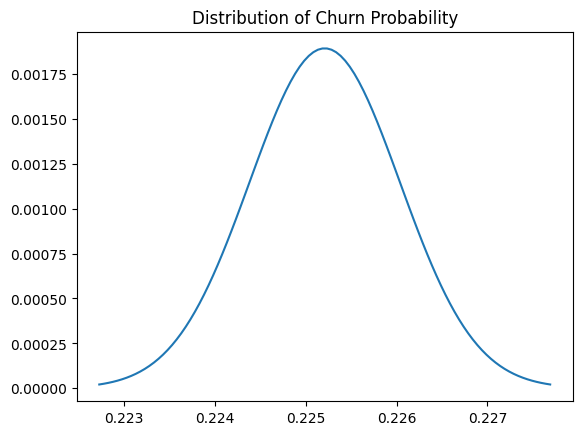

In [47]:
result, _ = test_model(mse_model, x_valid)
p_churn_hat = np.mean(result[:,1])
print(f"p_churn_hat: {p_churn_hat}")
E_p_churn = np.mean(result[:,0])
print(f"E_p_churn: {E_p_churn}")
plot_churn_distribution(len(valid_df), p)


From our confusion matrices and our distribution of churn probability, our best performing model, MSE, has a bias towards guessing "No" for Churn, which is more than we would expect from the dataset. In order to improve this we'll try undersampling the Churn = "No" datapoints.

In [ ]:
df_maj = train_df[train_df["Churn"] == "No"]
df_min = train_df[train_df["Churn"] == "Yes"]

df_maj_sample = df_maj.sample(n=len(df_min), random_state=42)
df_biased = pd.concat([df_min, df_maj_sample]).sample(frac=1, random_state=42).reset_index(drop=True)
print(df_biased)
